In [ ]:
!pip install pupil_apriltags

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pupil_apriltags import Detector

plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["image.cmap"] = "gray"

In [ ]:
# ============================================================
# Configuration
# ============================================================

REFERENCE_IMAGE_PATH = "/content/outdoor target.jpeg"
LIVE_IMAGE_PATH = "/content/perspective target.jpeg"

APRILTAG_SIZE_MM = 50.0


Reference: (1600, 847, 3)
Live      : (1116, 547, 3)


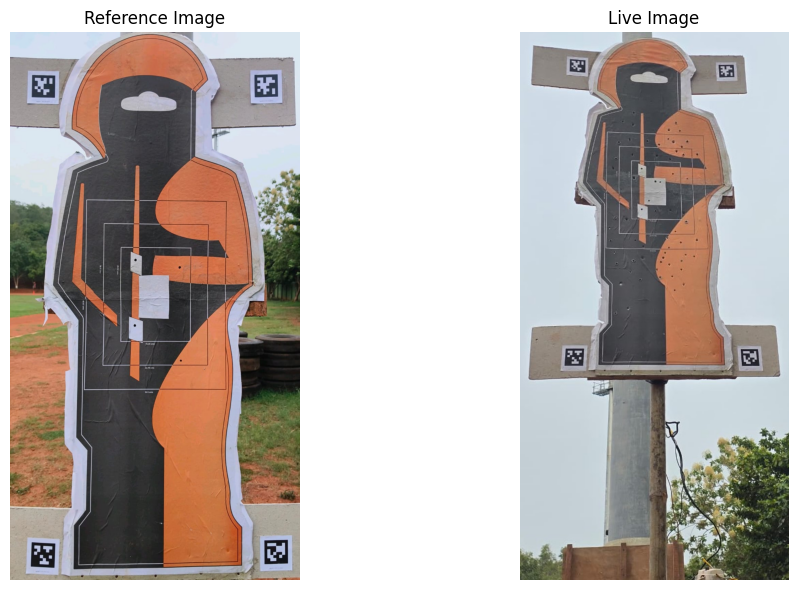

In [ ]:
# ============================================================
# Load Images
# ============================================================

reference_bgr = cv2.imread(REFERENCE_IMAGE_PATH)
live_bgr = cv2.imread(LIVE_IMAGE_PATH)

if reference_bgr is None:
    raise FileNotFoundError(REFERENCE_IMAGE_PATH)

if live_bgr is None:
    raise FileNotFoundError(LIVE_IMAGE_PATH)

reference_rgb = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2RGB)
live_rgb = cv2.cvtColor(live_bgr, cv2.COLOR_BGR2RGB)

print("Reference:", reference_rgb.shape)
print("Live      :", live_rgb.shape)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(reference_rgb)
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(live_rgb)
plt.title("Live Image")
plt.axis("off")

plt.tight_layout()

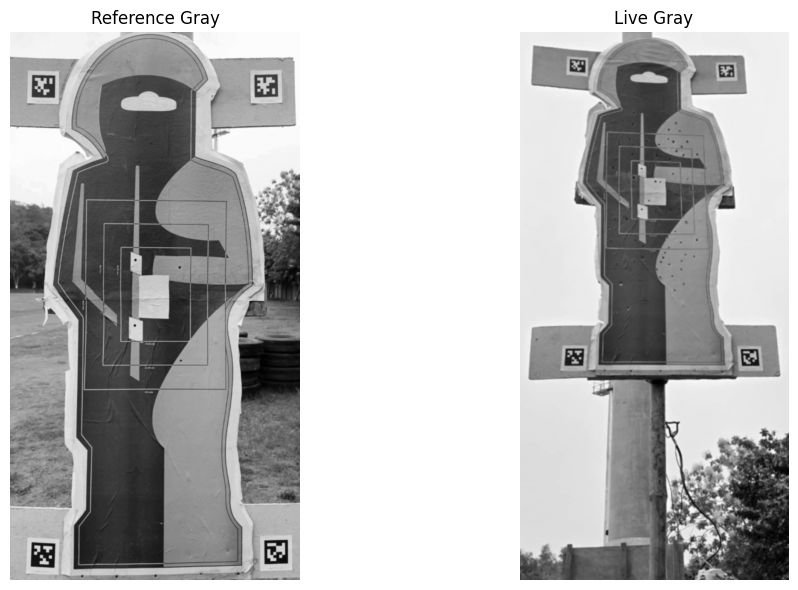

In [ ]:
# ============================================================
# Preprocessing
# ============================================================

reference_gray = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2GRAY)
live_gray = cv2.cvtColor(live_bgr, cv2.COLOR_BGR2GRAY)

reference_gray = cv2.GaussianBlur(reference_gray, (5,5), 0)
live_gray = cv2.GaussianBlur(live_gray, (5,5), 0)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(reference_gray)
plt.title("Reference Gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(live_gray)
plt.title("Live Gray")
plt.axis("off")

plt.tight_layout()

✓ All required AprilTags detected


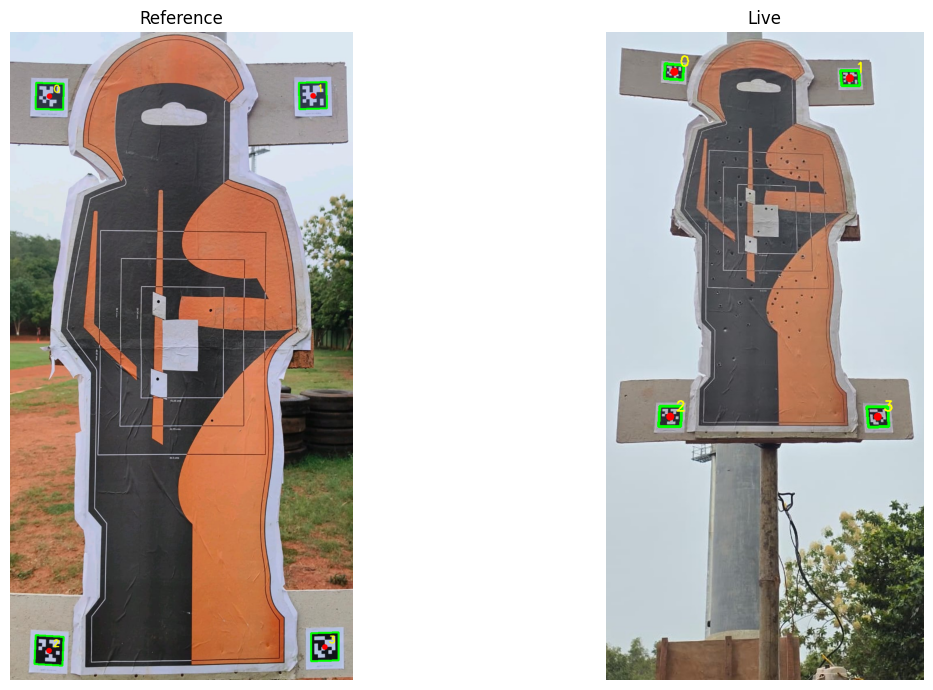

In [ ]:
# ============================================================
# AprilTag Detection
# ============================================================

detector = Detector(
    families="tag36h11",
    nthreads=4,
    quad_decimate=1.0,
    quad_sigma=0,
    refine_edges=True,
)

reference_tags = detector.detect(reference_gray)
live_tags = detector.detect(live_gray)

reference_tags_by_id = {
    tag.tag_id: tag
    for tag in reference_tags
}

live_tags_by_id = {
    tag.tag_id: tag
    for tag in live_tags
}

required_tags = [0,1,2,3]

for tag_id in required_tags:

    if tag_id not in reference_tags_by_id:
        raise RuntimeError(f"Reference image missing tag {tag_id}")

    if tag_id not in live_tags_by_id:
        raise RuntimeError(f"Live image missing tag {tag_id}")

print("✓ All required AprilTags detected")

# ============================================================
# Visualize AprilTag Detection
# ============================================================

def draw_tags(image, tags):

    display_img = image.copy()

    for tag in tags:

        corners = tag.corners.astype(np.int32)

        cv2.polylines(
            display_img,
            [corners],
            True,
            (0,255,0),
            3
        )

        center = tuple(tag.center.astype(int))

        cv2.circle(
            display_img,
            center,
            7,
            (255,0,0),
            -1
        )

        cv2.putText(
            display_img,
            str(tag.tag_id),
            (center[0]+10, center[1]-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,255,0),
            2
        )

    return display_img

reference_display = draw_tags(reference_rgb, reference_tags)
live_display = draw_tags(live_rgb, live_tags)

plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(reference_display)
plt.title("Reference")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(live_display)
plt.title("Live")
plt.axis("off")

plt.tight_layout()

In [ ]:
# ============================================================
# Build Correspondences
# ============================================================

reference_points = []
live_points = []


for tag_id in sorted(reference_tags_by_id.keys()):

    ref_tag = reference_tags_by_id[tag_id]
    live_tag = live_tags_by_id[tag_id]

    # AprilTag corners are already returned in a consistent order
    for ref_corner, live_corner in zip(ref_tag.corners, live_tag.corners):

        reference_points.append(ref_corner)
        live_points.append(live_corner)

reference_points = np.asarray(reference_points, dtype=np.float32)
live_points = np.asarray(live_points, dtype=np.float32)

print(f"Using {len(reference_points)} point correspondences")

print("Reference")
print(reference_points)

print()

print("Live")
print(live_points)

Using 16 point correspondences
Reference
[[  63.514282  190.49678 ]
 [ 131.22752   191.96379 ]
 [ 132.21414   127.18868 ]
 [  64.810356  125.61202 ]
 [ 714.81036   190.79318 ]
 [ 782.88165   188.65495 ]
 [ 781.6465    123.62481 ]
 [ 713.91      125.43736 ]
 [  60.797035 1560.7062  ]
 [ 129.84023  1564.391   ]
 [ 132.41393  1493.7861  ]
 [  63.43288  1489.9055  ]
 [ 743.3583   1553.7944  ]
 [ 811.9281   1551.6334  ]
 [ 811.5197   1482.7441  ]
 [ 743.08344  1484.3793  ]]

Live
[[100.90852   80.20005 ]
 [132.88326   82.971115]
 [133.28592   57.677315]
 [101.46627   54.92851 ]
 [405.56073   92.48074 ]
 [436.1909    92.079704]
 [434.53873   66.49208 ]
 [403.6974    66.96329 ]
 [ 90.51951  679.7521  ]
 [128.43065  679.7788  ]
 [130.49327  644.572   ]
 [ 92.99192  644.64264 ]
 [451.33252  680.126   ]
 [486.88068  679.93915 ]
 [484.09482  645.8615  ]
 [448.8421   645.9572  ]]


(np.float64(-0.5), np.float64(846.5), np.float64(1599.5), np.float64(-0.5))

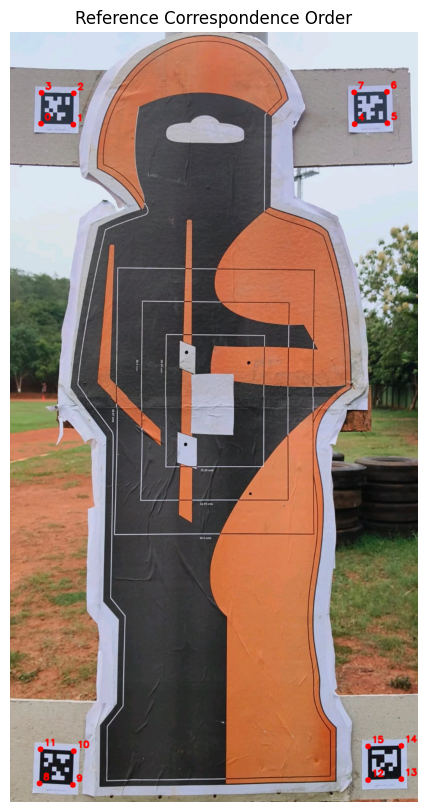

In [ ]:
# ============================================================
# Visualize Correspondence Ordering
# ============================================================

vis = reference_rgb.copy()

for idx, pt in enumerate(reference_points):

    p = tuple(np.round(pt).astype(int))

    cv2.circle(vis, p, 6, (255,0,0), -1)

    cv2.putText(
    vis,
    str(idx),
    (p[0] + 8, p[1] - 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (255, 0, 0),
    2,
    cv2.LINE_AA,
)

plt.figure(figsize=(10,10))
plt.imshow(vis)
plt.title("Reference Correspondence Order")
plt.axis("off")

In [ ]:
# ============================================================
# Compute Homography
# ============================================================

H, inlier_mask = cv2.findHomography(
    live_points,
    reference_points,
    method=cv2.RANSAC,
    ransacReprojThreshold=2.0,
)

if H is None:
    raise RuntimeError("Failed to compute homography.")

print("Homography computed successfully.")
print(H)

Homography computed successfully.
[[ 2.14625802e+00  4.11532416e-02 -1.55616237e+02]
 [-1.01615323e-01  2.67074061e+00 -1.29765242e+01]
 [-3.90760481e-05  2.18202294e-04  1.00000000e+00]]


(np.float64(-0.5), np.float64(846.5), np.float64(1599.5), np.float64(-0.5))

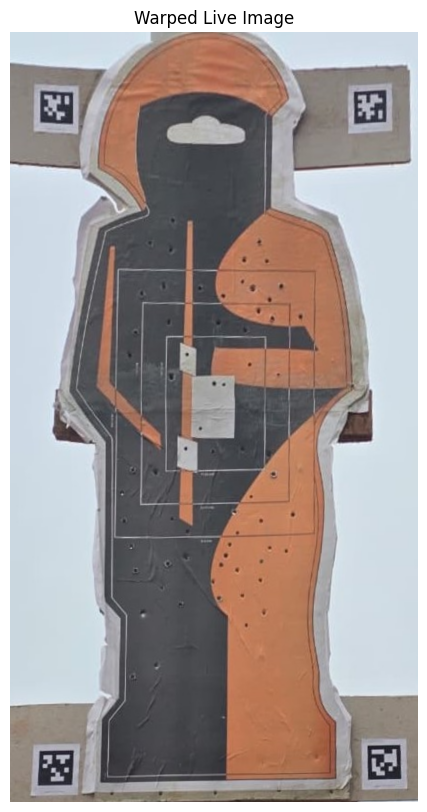

In [ ]:
# ============================================================
# Warp Live Image
# ============================================================

height, width = reference_rgb.shape[:2]

warped_rgb = cv2.warpPerspective(
    live_rgb,
    H,
    (width, height),
)

plt.figure(figsize=(8,10))
plt.imshow(warped_rgb)
plt.title("Warped Live Image")
plt.axis("off")

(np.float64(-0.5), np.float64(846.5), np.float64(1599.5), np.float64(-0.5))

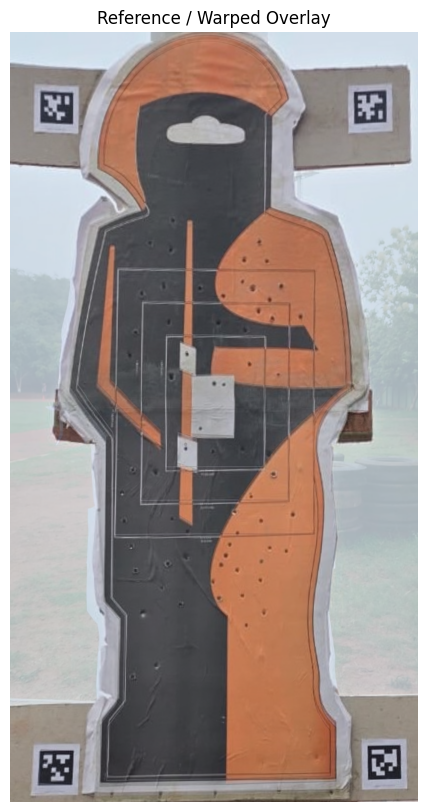

In [ ]:
# ============================================================
# Overlay Validation
# ============================================================

alpha = 0.2

overlay = cv2.addWeighted(
    reference_rgb,
    alpha,
    warped_rgb,
    1-alpha,
    0
)

plt.figure(figsize=(8,10))
plt.imshow(overlay)
plt.title("Reference / Warped Overlay")
plt.axis("off")

In [ ]:
# ============================================================
# Analyze AprilTag Geometry
# ============================================================


def polygon_area(points):
    """Shoelace formula."""
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) -
                     np.dot(y, np.roll(x, -1)))


def angle_between(v1, v2):
    """Returns angle in degrees."""
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)

    cos_theta = np.clip(np.dot(v1, v2), -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))


tag_measurements = []

for tag in reference_tags:

    corners = np.asarray(tag.corners)

    # ----------------------------------------
    # Edge lengths
    # ----------------------------------------

    edge_lengths = []

    for i in range(4):
        p1 = corners[i]
        p2 = corners[(i + 1) % 4]

        edge_lengths.append(np.linalg.norm(p2 - p1))

    edge_lengths = np.asarray(edge_lengths)

    avg_edge = edge_lengths.mean()
    std_edge = edge_lengths.std()

    # ----------------------------------------
    # Aspect ratio
    # ----------------------------------------

    width = (edge_lengths[0] + edge_lengths[2]) / 2
    height = (edge_lengths[1] + edge_lengths[3]) / 2

    aspect_ratio = width / height

    # ----------------------------------------
    # Polygon area
    # ----------------------------------------

    area = polygon_area(corners)

    # ----------------------------------------
    # Internal angles
    # ----------------------------------------

    angles = []

    for i in range(4):

        prev_pt = corners[(i - 1) % 4]
        curr_pt = corners[i]
        next_pt = corners[(i + 1) % 4]

        v1 = prev_pt - curr_pt
        v2 = next_pt - curr_pt

        angles.append(angle_between(v1, v2))

    angles = np.asarray(angles)

    avg_angle = angles.mean()
    angle_std = angles.std()

    # ----------------------------------------
    # Physical Scale Estimate
    # ----------------------------------------

    pixels_per_mm = avg_edge / APRILTAG_SIZE_MM

    tag_measurements.append({

        "Tag ID": int(tag.tag_id),

        "Avg Edge (px)": avg_edge,
        "Edge Std (px)": std_edge,

        "Aspect Ratio": aspect_ratio,

        "Area (px²)": area,

        "Avg Angle": avg_angle,
        "Angle Std": angle_std,

        "px/mm": pixels_per_mm,

    })

df = pd.DataFrame(tag_measurements)

df.round({
    "Avg Edge (px)": 2,
    "Edge Std (px)": 2,
    "Aspect Ratio": 3,
    "Area (px²)": 1,
    "Avg Angle": 2,
    "Angle Std": 2,
    "px/mm": 4
})


,Tag ID,Avg Edge (px),Edge Std (px),Aspect Ratio,Area (px²),Avg Angle,Angle Std,px/mm
0,0,66.21,1.37,1.042,4381.6,90.0,0.32,1.3242
1,1,66.57,1.38,1.042,4429.0,90.0,0.75,1.3313
2,2,69.93,0.82,0.977,4889.2,90.0,1.03,1.3987
3,3,68.84,0.37,0.991,4737.8,90.0,1.32,1.3768


In [ ]:
# ============================================================
# Weighted AprilTag Calibration
# ============================================================

def normalize_score(value, maximum):
    """
    Maps a metric to [0, 1].
    Smaller values receive higher scores.
    """
    return max(0.0, 1.0 - value / maximum)


calibration_rows = []

for _, row in df.iterrows():

    # --------------------------------------------
    # Individual Scores
    # --------------------------------------------

    aspect_error = abs(row["Aspect Ratio"] - 1.0)

    edge_ratio = row["Edge Std (px)"] / row["Avg Edge (px)"]

    angle_std = row["Angle Std"]

    aspect_score = normalize_score(aspect_error, 0.05)
    edge_score = normalize_score(edge_ratio, 0.03)
    angle_score = normalize_score(angle_std, 5.0)

    # --------------------------------------------
    # Overall Quality
    # --------------------------------------------

    quality = (
        0.50 * aspect_score +
        0.30 * edge_score +
        0.20 * angle_score
    )

    calibration_rows.append({

        **row.to_dict(),

        "Aspect Error": aspect_error,
        "Edge Ratio": edge_ratio,

        "Aspect Score": aspect_score,
        "Edge Score": edge_score,
        "Angle Score": angle_score,

        "Quality": quality

    })

# ------------------------------------------------
# Create calibrated dataframe
# ------------------------------------------------

df = pd.DataFrame(calibration_rows)

# ------------------------------------------------
# Normalized weights
# ------------------------------------------------

weights = df["Quality"].to_numpy()

weights = weights / weights.sum()

df["Weight"] = weights

# ------------------------------------------------
# Weighted Scale
# ------------------------------------------------

pixels_per_mm = np.average(
    df["px/mm"],
    weights=weights
)

mm_per_pixel = 1.0 / pixels_per_mm

# ------------------------------------------------
# Store calibration details
# ------------------------------------------------

tag_scale_data = []

for _, row in df.iterrows():

    tag_scale_data.append({

        "id": int(row["Tag ID"]),

        "pixels_per_mm": float(row["px/mm"]),

        "quality": float(row["Quality"]),

        "weight": float(row["Weight"]),

        "aspect_score": float(row["Aspect Score"]),

        "edge_score": float(row["Edge Score"]),

        "angle_score": float(row["Angle Score"])

    })

# ------------------------------------------------
# Display Results
# ------------------------------------------------

display(

    df[
        [
            "Tag ID",
            "Aspect Ratio",
            "Edge Std (px)",
            "Angle Std",
            "Quality",
            "Weight",
            "px/mm"
        ]
    ].round(4)

)

print("=" * 70)
print("REFERENCE SCALE CALIBRATION")
print("=" * 70)

print(f"Method            : Weighted AprilTag Geometry")
print(f"Tag Size          : {APRILTAG_SIZE_MM:.1f} mm")
print(f"Weighted px/mm    : {pixels_per_mm:.5f}")
print(f"Weighted mm/pixel : {mm_per_pixel:.5f}")

best = df.loc[df["Quality"].idxmax()]
worst = df.loc[df["Quality"].idxmin()]

print(f"Best Tag          : {int(best['Tag ID'])}")
print(f"Worst Tag         : {int(worst['Tag ID'])}")

,Tag ID,Aspect Ratio,Edge Std (px),Angle Std,Quality,Weight,px/mm
0,0.0,1.0422,1.3727,0.3170,0.3581,0.1692,1.3242
1,1.0,1.0419,1.3755,0.7543,0.3444,0.1627,1.3313
2,2.0,0.9769,0.8207,1.0311,0.6103,0.2884,1.3987
3,3.0,0.9910,0.3665,1.3230,0.8037,0.3797,1.3768


REFERENCE SCALE CALIBRATION
Method            : Weighted AprilTag Geometry
Tag Size          : 50.0 mm
Weighted px/mm    : 1.36681
Weighted mm/pixel : 0.73163
Best Tag          : 3
Worst Tag         : 1


In [ ]:
# ============================================================
# Blueprint Metadata
# ============================================================

blueprint = {

    "name": "PILSS Target",
    "version": "1.0",

    # --------------------------------------------------------
    # Reference Image
    # --------------------------------------------------------

    "reference": {

        "width_px": reference_bgr.shape[1],
        "height_px": reference_bgr.shape[0]

    },

    # --------------------------------------------------------
    # Physical Scale
    # --------------------------------------------------------

    "reference_scale": {

        "method": "weighted_apriltag",

        "tag_size_mm": APRILTAG_SIZE_MM,

        "pixels_per_mm": float(pixels_per_mm),

        "mm_per_pixel": float(mm_per_pixel),

        "tags": tag_scale_data

    },

    # --------------------------------------------------------
    # AprilTags
    # --------------------------------------------------------

    "apriltags": {

        "count": len(reference_tags),

        "tag_size_mm": APRILTAG_SIZE_MM,

        "tag_ids": sorted(int(tag.tag_id) for tag in reference_tags)

    },

    # --------------------------------------------------------
    # Blueprint Containers
    # --------------------------------------------------------

    "zones": [],

    "landmarks": [],

    "paper_contour": None

}

print("Blueprint initialized successfully.")

Blueprint initialized successfully.


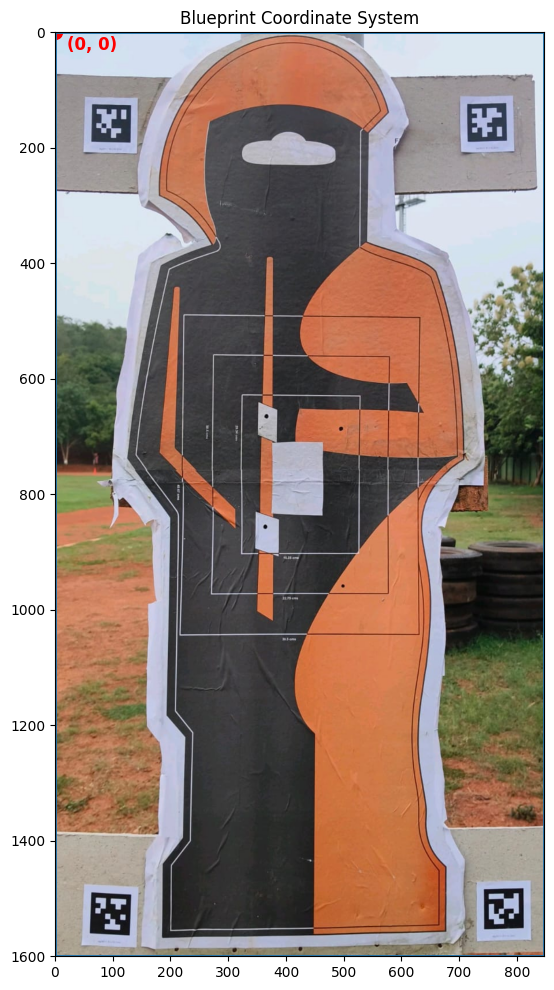

In [ ]:
# ============================================================
# Blueprint Coordinate System
# ============================================================

fig, ax = plt.subplots(figsize=(8, 12))

ax.imshow(reference_rgb)

# Draw origin
ax.scatter(0, 0, s=100, c="red")
ax.text(
    20,
    30,
    "(0, 0)",
    color="red",
    fontsize=12,
    weight="bold"
)

# Draw image boundary
height, width = reference_rgb.shape[:2]

ax.plot(
    [0, width, width, 0, 0],
    [0, 0, height, height, 0],
    linewidth=2
)

ax.set_title("Blueprint Coordinate System")
ax.set_xlim(0, width)
ax.set_ylim(height, 0)

plt.show()

In [ ]:
class BlueprintAuthor:
    zones
    current_zone
    current_polygon
    widgets
    figure
    axes
    blueprint

In [ ]:
# ============================================================
# Interactive Zone Authoring
# ============================================================



zones = []


def draw_current(canvas, pts, label):

    display = canvas.copy()

    # Existing vertices
    for p in pts:
        cv2.circle(display, tuple(p), 4, (0,255,0), -1)

    # Polygon preview
    if len(pts) >= 2:
        cv2.polylines(
            display,
            [np.array(pts, dtype=np.int32)],
            False,
            (0,255,0),
            2
        )

    cv2.putText(
        display,
        f"Zone {label}",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

    cv2.putText(
        display,
        "Left Click = Add | Right Click = Undo | ENTER = Finish | ESC = Cancel",
        (20,75),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,255,255),
        2
    )

    return display


while True:

    zone_label = input(
        "\nEnter zone label (or DONE): "
    ).strip()

    if zone_label.upper() == "DONE":
        break

    points = []

    canvas = reference_bgr.copy()

    def mouse(event, x, y, flags, param):

        global points

        if event == cv2.EVENT_LBUTTONDOWN:

            points.append([x,y])

        elif event == cv2.EVENT_RBUTTONDOWN:

            if len(points):
                points.pop()

    cv2.namedWindow("Zone Authoring")
    cv2.setMouseCallback("Zone Authoring", mouse)

    while True:

        display = draw_current(canvas, points, zone_label)

        cv2.imshow("Zone Authoring", display)

        key = cv2.waitKey(20)

        # ENTER
        if key == 13:

            if len(points) >= 3:

                break

            else:

                print("Polygon requires at least 3 vertices.")

        # ESC
        elif key == 27:

            points = []

            break

    cv2.destroyAllWindows()

    if len(points) < 3:

        print("Cancelled.")

        continue

    zones.append({

        "id": zone_label,

        "label": zone_label,

        "type": "score_zone",

        "score": int(zone_label),

        "polygon": points

    })

print()

print(f"{len(zones)} zones created.")


Enter zone label (or DONE): 5


(np.float64(-0.5), np.float64(846.5), np.float64(1599.5), np.float64(-0.5))

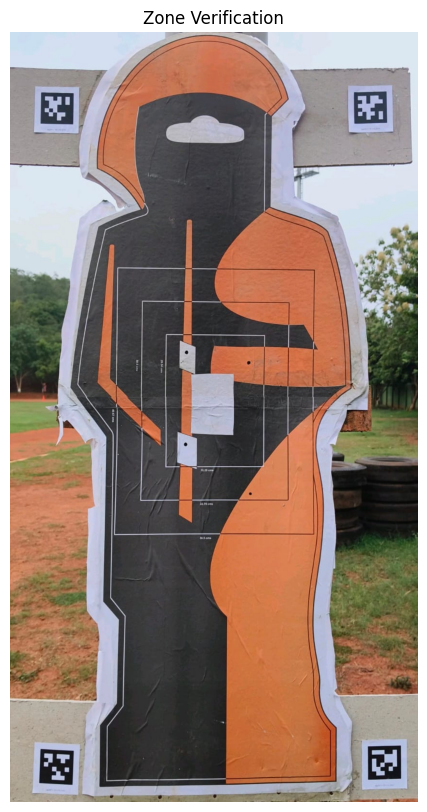

In [ ]:
# ============================================================
# Zone Visualization
# ============================================================

preview = reference_rgb.copy()

for zone in zones:

    polygon = np.array(
        zone["polygon"],
        dtype=np.int32
    )

    cv2.polylines(
        preview,
        [polygon],
        True,
        (0,255,0),
        2
    )

    overlay = preview.copy()

    cv2.fillPoly(
        overlay,
        [polygon],
        (0,255,0)
    )

    preview = cv2.addWeighted(
        overlay,
        0.20,
        preview,
        0.80,
        0
    )

    M = cv2.moments(polygon)

    if M["m00"] != 0:

        cx = int(M["m10"]/M["m00"])
        cy = int(M["m01"]/M["m00"])

        cv2.putText(
            preview,
            zone["label"],
            (cx,cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,0,0),
            2
        )

plt.figure(figsize=(8,10))
plt.imshow(preview)
plt.title("Zone Verification")
plt.axis("off")

In [ ]:
# ============================================================
# Commit Zones
# ============================================================

blueprint["zones"] = zones

print(f"{len(zones)} zones committed.")

for zone in zones:

    print(
        f"Zone {zone['label']} "
        f"({len(zone['polygon'])} vertices)"
    )